# Ejercicio 2

1. Informe los valores de intensidad de puntos particulares de la imagen (opcional: determine la posición en base al click del mouse).
2. Obtenga y grafique los valores de intensidad (*perfil de intensidad*) sobre una determinada fila o columna.
3. Grafique el *perfil de intensidad* para un segmento de interés cualquiera.

## Perfil de intensidad en una fila y columna

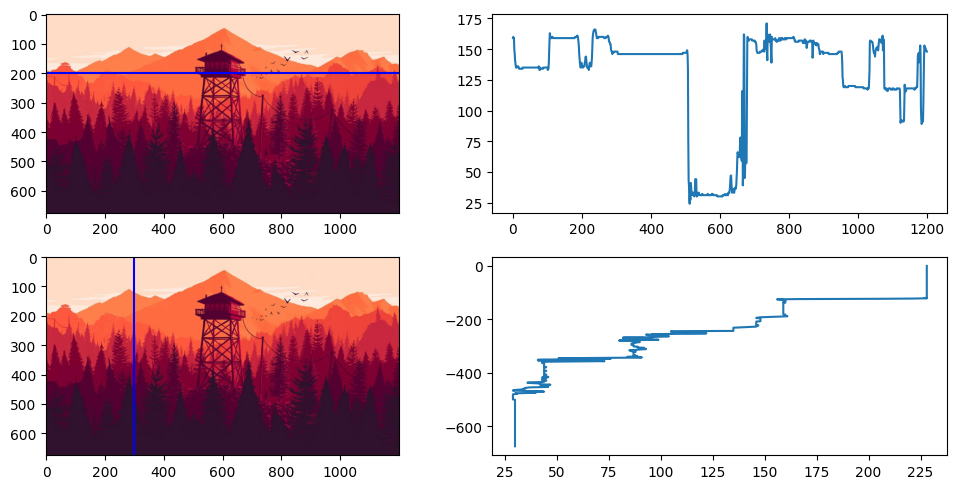

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread("firewatch.png")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

row = 200
col = 300

fig, ax = plt.subplots(2, 2)
fig.set_figwidth(10)
fig.set_figheight(5)

ax[0,0].imshow(img_rgb)
ax[0,0].plot([0, img_rgb.shape[1]-1], [row, row], c="blue")
ax[0,1].plot(img_gray[row,:])
ax[1,0].imshow(img_rgb)
ax[1,0].plot([col, col], [0, img_rgb.shape[0]-1], c="blue")
ax[1,1].plot(img_gray[:,col], -np.arange(img_gray.shape[0]))
fig.tight_layout()

## Perfil de intensidad en un segmento

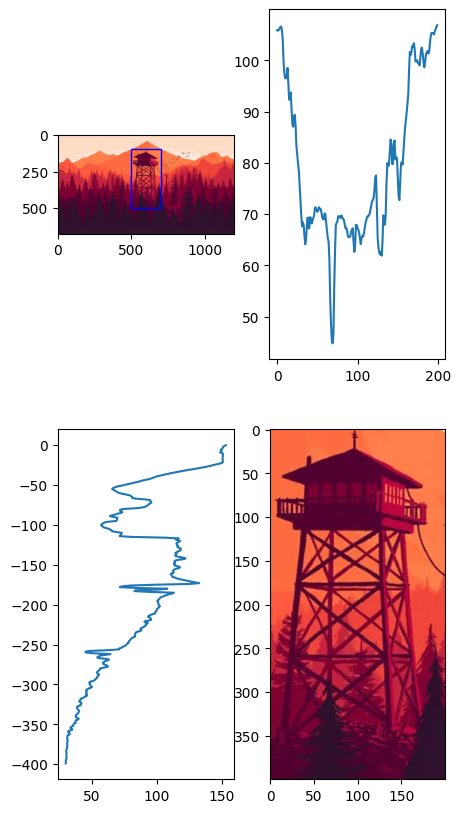

In [2]:
# (100,300), (300,50)
x,y,w,h = 500, 100, 200, 400
roi = img_rgb[y:y+h, x:x+w]
roi_gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)

fig, ax = plt.subplots(2,2)
fig.set_figwidth(5)
fig.set_figheight(10)
ax[0,0].imshow(img_rgb)
ax[0,0].add_patch(plt.Rectangle((x,y), w, h, edgecolor='blue', linewidth=1, fill=False))
ax[1,1].imshow(roi)
ax[0,1].plot(np.mean(roi_gray, axis=0)) # promedio horizontal
ax[1,0].plot(np.mean(roi_gray, axis=1), -np.arange(roi_gray.shape[0])); # promedio vertical

## Intensidad en puntos particulares

In [3]:
def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        # intensidad (por la escala de grises)
        I = img_gray[y, x]
        print(f"Posicion ({x}, {y}) - Intensidad {I}")

cv2.imshow('Ej 1', img) # se muestra la original
cv2.setMouseCallback('Ej 1', click_event)
cv2.waitKey(0)
cv2.destroyAllWindows()

Posicion (483, 637) - Intensidad 30
Posicion (498, 503) - Intensidad 30
Posicion (486, 423) - Intensidad 44
Posicion (493, 346) - Intensidad 88
Posicion (470, 289) - Intensidad 135
Posicion (476, 233) - Intensidad 146
Posicion (478, 65) - Intensidad 228
Posicion (436, 116) - Intensidad 239
